In [6]:
import networkx as nx
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler

In [12]:
df = pd.read_csv("data2.csv")
print(df.head())

                                      Place_Name  Latitude  Longitude
0  Graphic Era Deemed to be University, Dehradun   30.2685    77.9968
1                                  ISBT Dehradun   30.2861    77.9954
2                         Clement Town, Dehradun   30.2662    78.0075
3                       Sahranpur Road, Dehradun   30.2988    77.9945
4                          Clock Tower, Dehradun   30.3244    78.0411


In [13]:
df


,Place_Name,Latitude,Longitude
0,"Graphic Era Deemed to be University, Dehradun",30.2685,77.9968
1,ISBT Dehradun,30.2861,77.9954
2,"Clement Town, Dehradun",30.2662,78.0075
3,"Sahranpur Road, Dehradun",30.2988,77.9945
4,"Clock Tower, Dehradun",30.3244,78.0411
...,...,...,...
2362,Bageshwar,29.8415,79.7712
2363,Kanjhawala Crossing,28.7211,NaN
2364,Kashipur,29.2104,78.9618
2365,NaN,25.0451,79.4451


In [14]:
df.shape

(2367, 3)

In [15]:
df.size

7101

In [16]:
df.columns

Index(['Place_Name', 'Latitude', 'Longitude'], dtype='object')

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2367 entries, 0 to 2366
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Place_Name  2244 non-null   object 
 1   Latitude    2254 non-null   float64
 2   Longitude   2259 non-null   float64
dtypes: float64(2), object(1)
memory usage: 55.6+ KB


In [18]:
df.describe()

,Latitude,Longitude
count,2254.000000,2259.000000
mean,27.691830,79.804069
std,3.091533,4.241633
min,20.701100,8.000000
25%,25.241100,77.201100
50%,28.583100,78.041100
75%,30.321100,82.631100
max,34.551100,95.351100


In [19]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 15


In [21]:
# Remove duplicates
df = df.drop_duplicates()
df


,Place_Name,Latitude,Longitude
0,"Graphic Era Deemed to be University, Dehradun",30.2685,77.9968
1,ISBT Dehradun,30.2861,77.9954
2,"Clement Town, Dehradun",30.2662,78.0075
3,"Sahranpur Road, Dehradun",30.2988,77.9945
4,"Clock Tower, Dehradun",30.3244,78.0411
...,...,...,...
2353,Kanhaiya Nagar,28.6811,77.1511
2358,Banjarawala,NaN,78.0311
2360,NaN,26.9911,75.7611
2363,Kanjhawala Crossing,28.7211,NaN


In [22]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [23]:
print(df.isnull().sum())

Place_Name    120
Latitude      113
Longitude     108
dtype: int64


In [24]:
# Remove null values
df = df.dropna()

In [25]:
print(df.isnull().sum())

Place_Name    0
Latitude      0
Longitude     0
dtype: int64


In [28]:
df.loc[:, "Place_Name"] = df["Place_Name"].fillna("UNKNOWN")
df

,Place_Name,Latitude,Longitude
0,"Graphic Era Deemed to be University, Dehradun",30.2685,77.9968
1,ISBT Dehradun,30.2861,77.9954
2,"Clement Town, Dehradun",30.2662,78.0075
3,"Sahranpur Road, Dehradun",30.2988,77.9945
4,"Clock Tower, Dehradun",30.3244,78.0411
...,...,...,...
2343,Bandgaon Crossing,22.8811,85.3811
2344,Chakradharpur RS North,22.7011,85.6211
2345,Chaibasa Bypass North,22.5611,85.8111
2346,Jhinkpani RS North,22.4111,8.0000


In [32]:
df.loc[:, "Latitude"] = df["Latitude"].fillna(df["Latitude"].mean())
df.loc[:, "Longitude"] = df["Longitude"].fillna(df["Longitude"].mean())
df

,Place_Name,Latitude,Longitude
0,"Graphic Era Deemed to be University, Dehradun",30.2685,77.9968
1,ISBT Dehradun,30.2861,77.9954
2,"Clement Town, Dehradun",30.2662,78.0075
3,"Sahranpur Road, Dehradun",30.2988,77.9945
4,"Clock Tower, Dehradun",30.3244,78.0411
...,...,...,...
2343,Bandgaon Crossing,22.8811,85.3811
2344,Chakradharpur RS North,22.7011,85.6211
2345,Chaibasa Bypass North,22.5611,85.8111
2346,Jhinkpani RS North,22.4111,8.0000


In [33]:
df.shape

(2030, 3)

In [34]:
# valid coordinate
df = df[(df['Latitude'].between(-90, 90)) & (df['Longitude'].between(-180, 180))]

In [35]:
df['Latitude'] = df['Latitude'].astype(float)
df['Longitude'] = df['Longitude'].astype(float)
df

,Place_Name,Latitude,Longitude
0,"Graphic Era Deemed to be University, Dehradun",30.2685,77.9968
1,ISBT Dehradun,30.2861,77.9954
2,"Clement Town, Dehradun",30.2662,78.0075
3,"Sahranpur Road, Dehradun",30.2988,77.9945
4,"Clock Tower, Dehradun",30.3244,78.0411
...,...,...,...
2343,Bandgaon Crossing,22.8811,85.3811
2344,Chakradharpur RS North,22.7011,85.6211
2345,Chaibasa Bypass North,22.5611,85.8111
2346,Jhinkpani RS North,22.4111,8.0000


In [36]:
df["Place_Name"] = df["Place_Name"].str.upper().str.strip()

In [38]:
z1 = (df["Latitude"] - df["Latitude"].mean()) / df["Latitude"].std()
z2 = (df["Longitude"] - df["Longitude"].mean()) / df["Longitude"].std()
df = df[(np.abs(z1) <= 3) & (np.abs(z2) <= 3)]
df

,Place_Name,Latitude,Longitude
0,"GRAPHIC ERA DEEMED TO BE UNIVERSITY, DEHRADUN",30.2685,77.9968
1,ISBT DEHRADUN,30.2861,77.9954
2,"CLEMENT TOWN, DEHRADUN",30.2662,78.0075
3,"SAHRANPUR ROAD, DEHRADUN",30.2988,77.9945
4,"CLOCK TOWER, DEHRADUN",30.3244,78.0411
...,...,...,...
2342,KHUNTI MARKET NORTH,23.0711,85.2811
2343,BANDGAON CROSSING,22.8811,85.3811
2344,CHAKRADHARPUR RS NORTH,22.7011,85.6211
2345,CHAIBASA BYPASS NORTH,22.5611,85.8111


In [39]:
df.shape

(2017, 3)

In [40]:
Q1_lat = df["Latitude"].quantile(0.25)
Q3_lat = df["Latitude"].quantile(0.75)
IQR_lat = Q3_lat - Q1_lat
df = df[(df["Latitude"] >= Q1_lat - 1.5*IQR_lat) &
(df["Latitude"] <= Q3_lat + 1.5*IQR_lat)]
df


,Place_Name,Latitude,Longitude
0,"GRAPHIC ERA DEEMED TO BE UNIVERSITY, DEHRADUN",30.2685,77.9968
1,ISBT DEHRADUN,30.2861,77.9954
2,"CLEMENT TOWN, DEHRADUN",30.2662,78.0075
3,"SAHRANPUR ROAD, DEHRADUN",30.2988,77.9945
4,"CLOCK TOWER, DEHRADUN",30.3244,78.0411
...,...,...,...
2342,KHUNTI MARKET NORTH,23.0711,85.2811
2343,BANDGAON CROSSING,22.8811,85.3811
2344,CHAKRADHARPUR RS NORTH,22.7011,85.6211
2345,CHAIBASA BYPASS NORTH,22.5611,85.8111


In [41]:
# Min-Max Scaling
minmax = MinMaxScaler()
df_minmax = df.copy()
df_minmax[["Latitude", "Longitude"]] = minmax.fit_transform(df[["Latitude", "Longitude"]])
df_minmax

,Place_Name,Latitude,Longitude
0,"GRAPHIC ERA DEEMED TO BE UNIVERSITY, DEHRADUN",0.690787,0.243921
1,ISBT DEHRADUN,0.692058,0.243842
2,"CLEMENT TOWN, DEHRADUN",0.690621,0.244530
3,"SAHRANPUR ROAD, DEHRADUN",0.692975,0.243791
4,"CLOCK TOWER, DEHRADUN",0.694823,0.246443
...,...,...,...
2342,KHUNTI MARKET NORTH,0.171119,0.658509
2343,BANDGAON CROSSING,0.157401,0.664200
2344,CHAKRADHARPUR RS NORTH,0.144404,0.677860
2345,CHAIBASA BYPASS NORTH,0.134296,0.688674


In [42]:
# Standard Scaling
std = StandardScaler()
df_standard = df.copy()
df_standard[["Latitude", "Longitude"]] = std.fit_transform(df[["Latitude", "Longitude"]])
df_standard

,Place_Name,Latitude,Longitude
0,"GRAPHIC ERA DEEMED TO BE UNIVERSITY, DEHRADUN",0.827218,-0.460964
1,ISBT DEHRADUN,0.832898,-0.461327
2,"CLEMENT TOWN, DEHRADUN",0.826476,-0.458192
3,"SAHRANPUR ROAD, DEHRADUN",0.836997,-0.461560
4,"CLOCK TOWER, DEHRADUN",0.845260,-0.449485
...,...,...,...
2342,KHUNTI MARKET NORTH,-1.495768,1.426678
2343,BANDGAON CROSSING,-1.557091,1.452591
2344,CHAKRADHARPUR RS NORTH,-1.615187,1.514785
2345,CHAIBASA BYPASS NORTH,-1.660372,1.564021


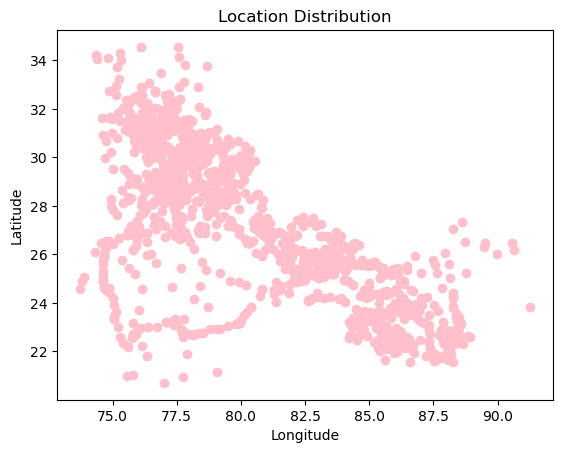

In [43]:
plt.scatter(df["Longitude"], df["Latitude"],color="pink")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Location Distribution")
plt.show()

In [44]:
df.shape

(2017, 3)

In [45]:
df.size

6051

In [46]:
corr = df[["Latitude", "Longitude"]].corr()
print(corr)

           Latitude  Longitude
Latitude   1.000000  -0.695129
Longitude -0.695129   1.000000


In [51]:
df = df.copy()
df = df.dropna(subset=["Place_Name", "Latitude", "Longitude"])
df = df.reset_index(drop=True)